# Proyecto 1: Regresión y Descenso del Gradiente
#### Laurie Camila Hernández Pacheco - A01286569
#### Fernando Álvarez Ruiz - A01286754

## 0. Setup

En esta sección, se importarán las librerías necesarias para llevar a cabo las actividades del código. Las librerías a utilizar son:
- `numpy`: para manipulación de números y vectores.

In [650]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats

# 1. Implementación de algoritmos

En esta sección, se llevará a cabo el desarrollo e implementación del Descenso de Gradiente, así como también de regresión lineal y logística.

### 1.1 Descenso de Gradiente
En esta sección, se desarrolló el descenso de gradiente para la regresión lineal y regresión logística.

In [ ]:
def FitLineal(self, X, y):
        """
        función que se usa para el training con los siguiente sparámetros:
        X: matriz de valores de X
        y: los valores reales d lo que queremos
        en fit, definimos siempre los weights como array de 0s usando numpy y el bias como 0.
        """
        n_samples, n_features = X.shape # me da la forma de la matriz X en samples (rows) y features (columns)
        self.weights = np.zeros(n_features)
        self.bias = 0

        # incluímos un for loop para repetir n_iter veces el entrenamiento del modelo (modificar weights y bias)
        for _ in range(self.n_iter):
            # calculamos la predicción de y con el producto punto entre la matriz X y los pesos, le sumamos le bias (el epsilon)
            # nota: el producto punto en python hace la sumatoria de todas las multiplicaciones dentro del range de la matrix
            y_pred = np.dot(X, self.weights) + self.bias

            # empezamos a definir dw y db (cambio en weights y bias) para poder calcular el gradient
            dw = (1/n_samples) * np.dot(X.T, (y_pred-y)) # X.T = traspuesta de X para evitar problemas de dimensiones
            db = (1/n_samples) * np.sum(y_pred - y)

            # finalmente actualizamos los weights y bias.
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

#en esta sección empieza el fit para la regresión logística

def sigmoid(x):
  # para evitar runtime error podemos poner el np.clip
  x = np.clip(x, -500, 500)
  # la fórmula matemática de la función sigmoide para x
  return (1/(1+np.exp(-x)))

def FitLogistico(self, X, y):
        # me da la forma de la matriz X en samples (rows) y features (columns)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # incluímos un for loop para repetir n_iter veces el entrenamiento del modelo
        for _ in range (self.n_iter):
            # predicciones lineales sin haber aplicado la sigmoid
            linear_preds = np.dot(X, self.weights) + self.bias
            # para las verdaderas predictions, vamos a ahora sí hacer uso de la sigmoid funct.
            predictions = sigmoid(linear_preds)

            # empezamos a definir dw y db (cambio en weights y bias) para poder calcular el gradient
            dw = (1/n_samples) * np.dot(X.T, (predictions - y))
            db = (1/n_samples) * np.sum(predictions - y)

            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

### 1.2 Regresión Lineal

En esta sección, se desarrolló la clase `LinearRegression()` que es una implementación manual del algoritmo de regresión lineal. Utiliza tres funciones fundamentales:
- `__init__`: función que inicializa la clase. El constructor jiji
- `fit`: función que permite ir entrenando los datos con los parámetros de la database que ya conocemos
- `predict`: función que utiliza el modelo obtenido en `fit` para obtener la predicción a un nuevo dataset.

In [652]:
# empezamos creando la clase del modelo que vamos a tener
class RegresionLineal():
    def __init__(self, lr = 0.001, n_iter = 1000):
        """
        Creamos la función de incialización donde tenemos dos parámetros importantes:
        lr: learning rate (de 0 a 1)
        n_iter = número de iteraciones
        """
        self.lr = lr
        self.n_iter = n_iter

        # definimos también que existen pesos entre las variables junto con el bias
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """
        función que se usa para el training con los siguiente sparámetros:
        X: matriz de valores de X
        y: los valores reales d lo que queremos

        en fit, definimos siempre los weights como array de 0s usando numpy y el bias como 0.
        """
        n_samples, n_features = X.shape # me da la forma de la matriz X en samples (rows) y features (columns)
        self.weights = np.zeros(n_features)
        self.bias = 0

        # incluímos un for loop para repetir n_iter veces el entrenamiento del modelo (modificar weights y bias)
        for _ in range(self.n_iter):
            # calculamos la predicción de y con el producto punto entre la matriz X y los pesos, le sumamos le bias (el epsilon)
            # nota: el producto punto en python hace la sumatoria de todas las multiplicaciones dentro del range de la matrix
            y_pred = np.dot(X, self.weights) + self.bias

            # empezamos a definir dw y db (cambio en weights y bias) para poder calcular el gradient
            dw = (1/n_samples) * np.dot(X.T, (y_pred-y)) # X.T = traspuesta de X para evitar problemas de dimensiones
            db = (1/n_samples) * np.sum(y_pred - y)

            # finalmente actualizamos los weights y bias.
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict(self, X):
        """
        función que se usa para inferir utilizando el parámetro:
        X: matriz de datos que usaremos para ver si funciona o no .
        """

        y_pred = np.dot(X, self.weights) + self.bias
        return y_pred

### 1.3 Regresión Logística

La regresión logística es un algoritmo de clasificación que permite catalogar outcomes, como por ejemplo determinar si un correo es spam, casos yes/no, true/false, etc.

En la logistic regression lo que queremos hacer son probabilities en ves de un valor en específico. Para esto, vamos a poner nuestros valores **adentro** de la **Sigmoid Function** que se ve algo así:

$$
\sigma (x) = \frac{1}{1+e^{-x}}
$$

Toma valores únicamente de 0 a 1. Esto después hace que nuestro $\hat{y}$ en vez de ser como en la regresión lineal $\hat{y} = wX + b$ se convierta en lo siguiente:

$$
\hat{y} = h_{\theta}(x) = \frac{1}{1+e^{-wx+b}}
$$

Para el cálculo del error, no utilizamos el MSE como en la linear regression, sino que hacemos uso de algo llamado **cross entropy**. Es un cálculo más complicado y se determina con la siguiente fórmula:
$$
J(w, b) = J(\theta) = \frac{1}{N} \sum_{i=1}^{n} [y^i log(h_{\theta} (x^i)) + (1-y^i) log (1-h_{\theta}(x^i))]
$$

Aquí en la regresión logística también hacemos uso del gradient descent, nuevamente relacionándolo al weight y bias.  

A continuación se encuentra la implementación de la clase `LogisticRegression`que se estará trabajando para ver cómo funciona esto:

In [653]:
def sigmoid(x):
  # para evitar runtime error podemos poner el np.clip
  x = np.clip(x, -500, 500)
  return (1/(1+np.exp(-x)))

class RegresionLogistica():

    def __init__(self, lr = 0.1, n_iter = 10000):

        self.lr = 0.1
        self.n_iter = 10000
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range (self.n_iter):
            linear_preds = np.dot(X, self.weights) + self.bias
            # para las verdaderas predictions, vamos a ahora sí hacer uso de la sigmoid funct.
            predictions = sigmoid(linear_preds)

            dw = (1/n_samples) * np.dot(X.T, (predictions - y))
            db = (1/n_samples) * np.sum(predictions - y)

            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        linear_pred = np.dot(X, self.weights) + self.bias

        # lo que tenemos en y_pred son probabilidades
        y_pred = sigmoid(linear_pred)
        return np.column_stack((1 - y_pred, y_pred))

    def predict(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias

        # lo que tenemos en y_pred son probabilidades
        y_pred = sigmoid(linear_pred)

        """
        Debido a la naturaleza de la sigmoid function y de la logistic regression, vamos a clasificar con base en esta probabilidad a
        nuestras respuestas. Entonces, en este caso determinaremos que una categoría es si la probabilidad es entre 0 y 0.5, mientras que
        otra categoría es si la probabilidad cae arriba de 0.5
        """

        class_pred = [0 if y<=0.5 else 1 for y in y_pred]
        return class_pred

# 2. Limpieza de Datos

En esta sección, se trabajará con dos datasets correspondientes para el modelo de regresión lineal y el modelo de regresión logística binomial.  

Para el modelo de regresión lineal, se trabajará con el dataset *California Housing Prices*, información recuperada en un censo realizado en 1990 en California. Mientras tanto, para el modelo de regresión logística se trabajará con el dataset *Telco Customer Churn*, que describe información de clientes de una empresa de telecomunicaciones, con sus características y su futuro de renovación.

## 2.1 Regresión Lineal: California Housing Prices

Este dataset contiene un total de 10 columnas distintas, que se describen a continuación:
1. `longitude`: la localización del lugar con respecto a la dirección Oeste desde el meridiano de Greenwich. Mayor valor $\rightarrow$ más hacia el oeste.
2. `latitude`: la localización del lugar con respecto a la dirección Norte desde el ecuador. Mayor valor $\rightarrow$ más hacia el norte.
3. `housing_median_age`: edad mediana de las casas en un bloque. Más bajo $\rightarrow$ más recientes son las construcciones.  
4. `total_rooms`: número de habitaciones dentro de un bloque.
5. `total_bedrooms`: número de dormitorios dentro de un bloque.
6. `population`: número de personas que viven en un bloque.
7. `households`: número de hogares dentro de un bloque.
8. `median_income`: ingreso mediano de los hogares dentro de un bloque (medido en decenas de miles de dólares estadounidenses).
9. `median_house_value`: valor mediano de las casas dentro de un bloque (medido en dólares estadounidenses).
10. `ocean_proximity`: ubicación de la casa con respecto al óceano o mar.

Todas estas variables son de tipo punto flotante, a excepción de `ocean_proximity` que se divide en 5 categorías distintas: `['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']`.

Para evaluar la implementación manual y contrastar los resultados del modelo con respecto a `sklearn`, se debe inicialmente de limpiar la base de datos con la que se trabajará.

In [654]:
df1 = pd.read_csv('datos_proyecto/housing.csv')
print("Dimensiones del dataframe: ", df1.shape)
print("\nDescripción estadística del dataset")
df1.describe()

Dimensiones del dataframe:  (20640, 10)

Descripción estadística del dataset


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Se identificaron 20640 filas distintas dentro del dataset, junto cn 10 columnas diferentes. A continuación, se identificará la cantidad de filas duplicadas, así como los valores nulos que existen por columnas.

In [655]:
df1.duplicated().sum()
df1.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


En total, se identificaron 0 valores duplicados, y la mayoría de columnas tiene 0 valores nulos. Sin embargo, la columna de `total_bedrooms` tiene un total de 207 valores nulos. Al ser un porcentaje muy bajo de datos totales (pues existen más de 20,000 filas), estos valores nulos serán eliminados.

In [656]:
df1 = df1.dropna(subset=["total_bedrooms"])
print("\nDescripción estadística del dataset (sin NaNs)")
df1.describe()


Descripción estadística del dataset (sin NaNs)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Finalmente, para mantener todos los datos con la misma unidad de medida (específicamente aquellos datos en USD), se multiplicará la columna de `median_income` por $10,000$, puesto que los valores se encuentran en decenas de miles de dólares, mientras que para la columna `median_house_value` se encuentran directamente en dólares.

In [657]:
df1["median_income"] = df1["median_income"] * 10000
print("\nDescripción estadística del dataset (sin NaNs y en USD)")
df1.describe()


Descripción estadística del dataset (sin NaNs y en USD)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,38711.616013,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,18992.912493,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,4999.000000,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,25637.000000,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,35365.000000,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,47440.000000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,150001.000000,500001.000000


## 2.2 Regresión Logística: Telco Customer Churn

El dataset está compuesto por 21 columnas, con algunas siendo numéricas y las otras categóricas:

1. `customerID`: el ID asignado al usuario por la compañía
2. `gender`: el género del cliente
3. `SeniorCitizen`: variable que es 1 si el cliente es de la tercera edad y 0 si no
4. `Partner`: variable que indica si el cliente tiene pareja o está casado en el hogar de la línea
5. `Dependents`: indica si el cliente tiene personas que dependan de él financieramente
6. `Tenure`: la cantidad de meses seguidos que el cliente ha contratado la línea
7. `PhoneService`: indica si el cliente tiene servicio telefónico
8. `MultipleLines`: indica si el cliente tiene 0, 1 o varias lineas telefónicas
9. `InternetService`: el tipo de conexión a internet del cliente
10. `OnlineSecurity`: add-on de seguridad en línea
11. `OnlineBackup`: servicio de Backup en la nube
12. `DeviceProtection`: sistema de protección del dispositivo
13. `TechSupport`: plan de soporte técnico
14. `StreamingTV`: servicio de streaming de TV
15.  `StreamingMovies`: lo mismo con películas
16. `Contract`: frecuencia de pago en el contrato
17. `PaperlessBilling`: recibos electrónicos
18. `PaymentMethod`: método de pago
19. `MonthlyCharges`: costo mensual del plan
20. `TotalCharges`: costo total que han pagado hasta ahora
21. `Churn`: si el cliente ha decidido abandonar el servicio

Las variables de `tenure`, `MonthlyCharges` y `SeniorCitizen` son numéricas, mientras que las demás son categóricas. A pesar de esto, muchas de las categóricas como `Churn` solo se clasifican como preguntas de Sí/No, por lo que se pueden convertir a numéricas con facilidad. Además, `TotalCharges` debería de ser un número, por lo que la fila debería ser cambiada a tal tipo de dato

Como primer paso, se extraerá el dataset y se limpiará para su mejor uso de la regresión logística.

In [658]:
df2 = pd.read_csv('datos_proyecto/Telco-Customer-Churn.csv')

df2["TotalCharges"] = pd.to_numeric(df2["TotalCharges"], errors="coerce")

print("Dimensiones del dataframe: ", df2.shape)
print("\nDescripción estadística del dataset")

df2.describe()

Dimensiones del dataframe:  (7043, 21)

Descripción estadística del dataset


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Ahora se detectarán los valores nulos para ser eliminados después

In [659]:
df2.duplicated().sum()
df2.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Parece que por la conversión a valor numérico se han generado valores nulos, pero pueden ser eliminados. Además, se irán procesando las columnas categóricas de Sí/No a columnas numéricas

In [660]:
df2 = df2.dropna()
df2["Churn"] = df2["Churn"].map({"Yes": 1, "No": 0})
df2["Partner"] = df2["Partner"].map({"Yes": 1, "No": 0})
df2["Dependents"] = df2["Dependents"].map({"Yes": 1, "No": 0})
df2["PhoneService"] = df2["PhoneService"].map({"Yes": 1, "No": 0})
df2["PaperlessBilling"] = df2["PaperlessBilling"].map({"Yes": 1, "No": 0})
print("\nDescripción estadística del dataset (sin NaNs)")
df2.describe()


Descripción estadística del dataset (sin NaNs)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


Ahora se removerán categorías que parecen no aportar a la información necesaria del modelo y se procesarán las columnas para que las tome el modelo. Esto se hará estandarizando las numéricas y encodeando las categóricas con One-Hot Encoding. También se separará la variable objetivo del resto de los datos

In [661]:
from sklearn.preprocessing import StandardScaler

df2 = df2.drop(columns=({"customerID", "gender"}))

y2 = df2["Churn"]
X2 = df2.drop(columns="Churn")

categorical_cols = X2.select_dtypes(include=["object"]).columns
numerical_cols = X2.select_dtypes(include=["int64", "float64"]).columns

X2 = pd.get_dummies(X2, columns=categorical_cols, drop_first=True)

scaler2 = StandardScaler()
X2[numerical_cols] = scaler2.fit_transform(X2[numerical_cols])

# 3. Entrenamiento del Modelo

En esta sección se realizará el entrenamiento del modelo, seleccionando las variables dependientes e independientes de cada dataset. Nuevamente, se dividirá en dos secciones: regresión lineal y regresión logística, trabajando con sus datasets correspondientes.

## 3.1 Regresión lineal

Para este dataset, se eligió la variable dependiente `median_house_value` que representa el valor mediano de una casa, y como variable independiente se eligió `median_income`, que es el ingreso mediano. Por lo tanto, para el entrenamiento se intentará predecir mediante regresión lineal el valor mediano de una casa con base en el ingreso mediano de un bloque durante 1990.  

A continuación, se muestra un gráfico del

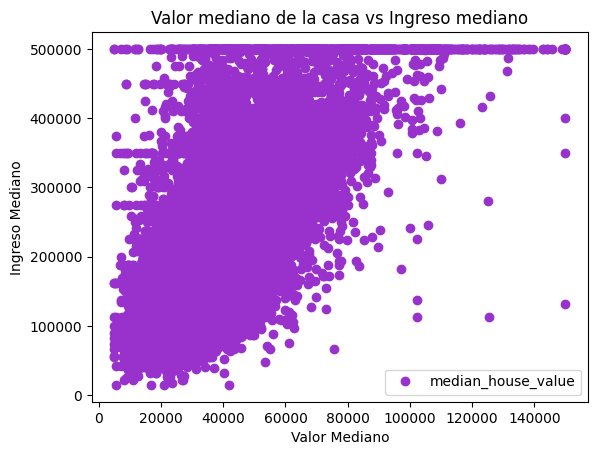

In [662]:
df1.plot(x='median_income', y='median_house_value', style='o', color ="darkorchid")
plt.title('Valor mediano de la casa vs Ingreso mediano')
plt.xlabel('Valor Mediano')
plt.ylabel('Ingreso Mediano')
plt.show()

Primero se separan la variable independiente `median_house_value` (X) y la dependiente `median_income` (y), y se hace un split 80/20 para tener datos de entrenamiento y prueba.  

Antes de entrenar, se aplica StandardScaler a X y a y. Esto es necesario porque el modelo manual usaGD, y dado que las variables tienen escalas muy diferentes, el algoritmo tarda mucho más en converger o simplemente no lo hace. El scaler transforma los datos para que tengan media $0$ y desviación estándar $1$, lo que hace el entrenamiento mucho más estable.  

Un detalle importante: solo se hace `fit_transform` en los datos de entrenamiento y solo `transform` en los de prueba. Esto es para no "contaminar" el modelo con información del test set, pues el scaler debe aprender la media y desviación estándar únicamente de los datos de entrenamiento.  

Finalmente se entrenan ambos modelos con los datos escalados: LinearRegression de sklearn (que usa solución analítica exacta) y la implementación manual RegresionLineal (que usa GD con lr=0.1 y 1000 iteraciones), y se generan las predicciones sobre el test set.

In [663]:
X = df1['median_house_value'].values.reshape(-1,1)
y = df1['median_income'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

regsklearn = LinearRegression()
regsklearn.fit(X_train_sc, y_train_sc)
regmanual = RegresionLineal(lr = 0.001, n_iter = 1000)
regmanual.fit(X_train_sc, y_train_sc)

y_pred_sklearn = regsklearn.predict(X_test_sc)
y_pred_manual = regmanual.predict(X_test_sc)

## 3.2 Regresión Logística

Al ser un dataset de detección de Churn, se buscará utilizar las demás variables para predecir si un cliente va a dejar de renovar. Se dividirán los datos en train y test con una proporción 75-25. Además, se entrena el modelo con ambas clases

In [664]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.25, random_state=16)

X_train2 = X_train2.astype(float).to_numpy()
X_test2 = X_test2.astype(float).to_numpy()

y_train2 = y_train2.astype(float).to_numpy()
y_test2 = y_test2.astype(float).to_numpy()

logsklearn = LogisticRegression()
logsklearn.fit(X_train2, y_train2)
logmanual = RegresionLogistica(lr = 0.1, n_iter = 10000)
logmanual.fit(X_train2, y_train2)

y_probs_sklearn2 = logmanual.predict_proba(X_test2)[:, 1]
y_pred_sklearn2 = logsklearn.predict(X_test2)
y_probs_manual2 = logmanual.predict_proba(X_test2)[:, 1]
y_pred_manual2 = logmanual.predict(X_test2)


# 4. Evaluación y Comparación de los Modelos

En esta sección, se evaluarán y compararán los modelos manuales con su contraparte en `sklearn`, utilizando distintas métricas de evaluación y visualizando

## 4.1 Regresión lineal

Dado que los modelos se entrenaron con datos escalados, las predicciones también salen en escala normalizada.
Para interpretarlas y compararlas contra los valores reales, se aplica `inverse_transform` de `scaler_y`,
que revierte la transformación y regresa los valores a su escala original.

Lo mismo aplica para los coeficientes: la pendiente e intersección que guardan los modelos internamente
corresponden al espacio escalado, por lo que se convierten al espacio original usando la media y
desviación estándar de ambos scalers:

- `w_original = w_scaled * (std_y / std_X)`
- `b_original = mean_y - w_original * mean_X`

Esto permite comparar directamente los parámetros de ambos modelos.

Para evaluar el desempeño se calculan cuatro métricas estándar de regresión:
- **MSE / RMSE**: miden el error cuadrático promedio; RMSE tiene la ventaja de estar en las mismas unidades que y.
- **MAE**: error absoluto promedio, menos sensible a outliers que RMSE.
- **$R^2$**: indica qué proporción de la varianza de y explica el modelo (1.0 sería perfecto).

Si ambos modelos convergen correctamente, todas las métricas deben ser idénticas entre sklearn y el modelo manual.

In [665]:
y_pred_sklearn = scaler_y.inverse_transform(
    regsklearn.predict(X_test_sc).reshape(-1, 1)
)
y_pred_manual = scaler_y.inverse_transform(
    regmanual.predict(X_test_sc).reshape(-1, 1)
)

std_X  = scaler_X.scale_[0]
mean_X = scaler_X.mean_[0]
std_y  = scaler_y.scale_[0]
mean_y = scaler_y.mean_[0]

w_sk_original = regsklearn.coef_[0] * (std_y / std_X)
b_sk_original = mean_y - w_sk_original * mean_X

w_original = regmanual.weights[0] * (std_y / std_X)
b_original = mean_y - w_original * mean_X

def metricas(y_true, y_pred):
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    mse    = mean_squared_error(y_true, y_pred)
    rmse   = np.sqrt(mse)
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    return dict(mse=mse, rmse=rmse, mae=mae, r2=r2)

m_sk = metricas(y_test, y_pred_sklearn)
m_mn = metricas(y_test, y_pred_manual)

print("=========================================")
print("               sklearn       manual")
print("=========================================")
print(f"pendiente  {w_sk_original:>12.4f}  {w_original:>12.4f}")
print(f"intercept  {b_sk_original:>12.4f}  {b_original:>12.4f}")
print("-----------------------------------------")
print(f"R²         {m_sk['r2']:>12.4f}  {m_mn['r2']:>12.4f}")
print(f"MAE        {m_sk['mae']:>12.4f}  {m_mn['mae']:>12.4f}")
print(f"RMSE       {m_sk['rmse']:>12.4f}  {m_mn['rmse']:>12.4f}")
print(f"MSE        {m_sk['mse']:>12.4f}  {m_mn['mse']:>12.4f}")
print("=========================================")

               sklearn       manual
pendiente        0.1133        0.0717
intercept    15245.9934    23856.3931
-----------------------------------------
R²               0.4776        0.4137
MAE          10093.5785    10801.7873
RMSE         13670.8633    14482.9403
MSE        186892502.5900  209755559.2629


Estos resultados de métricas indican una gran similitud entre el modelo manual y el modelo de `sklearn`, reflejando cómo el modelo manual aunque toma más tiempo computacional, converge al mismo resultado que el que presenta `sklearn`.

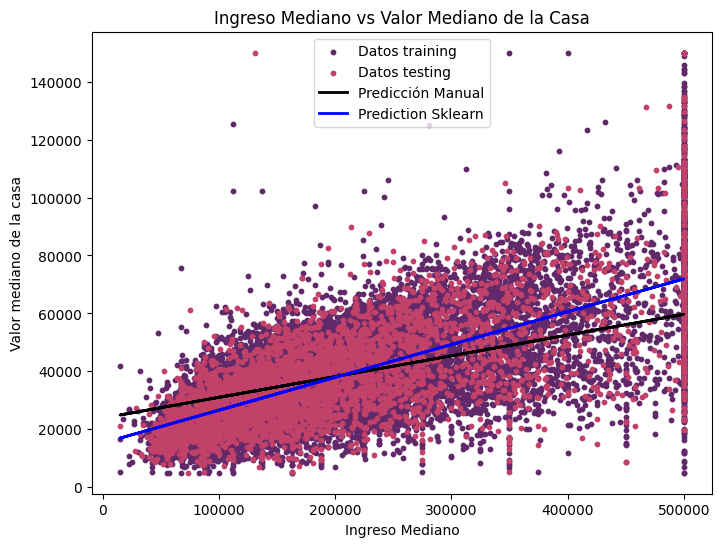

In [666]:

cmap = plt.get_cmap('flare')
fig = plt.figure(figsize= (8,6))
m1 = plt.scatter(X_train, y_train, color= cmap(0.9), s = 10, label = "Datos training")
m2 = plt.scatter(X_test, y_test, color = cmap(0.5), s= 10, label = "Datos testing")
plt.plot(X_test, y_pred_manual, color = 'black', linewidth = 2, label = "Predicción Manual")
plt.plot(X_test, y_pred_sklearn, color = 'blue', linewidth = 2, label = "Prediction Sklearn")
plt.xlabel("Ingreso Mediano")
plt.ylabel("Valor mediano de la casa")
plt.title("Ingreso Mediano vs Valor Mediano de la Casa")
plt.legend()
plt.show()

## 4.2 Regresión logística
Ahora, se realiza esta comparación con la regresión logística

In [667]:
cnf_matrix = metrics.confusion_matrix(y_test2, y_pred_sklearn2)
print("Matriz de confusión scikit:\n", cnf_matrix, "\n")

cnf_matrix2 = metrics.confusion_matrix(y_test2, y_pred_manual2)
print("Matriz de confusión manual:\n", cnf_matrix2)

Matriz de confusión scikit:
 [[1131  151]
 [ 207  269]] 

Matriz de confusión manual:
 [[1133  149]
 [ 206  270]]


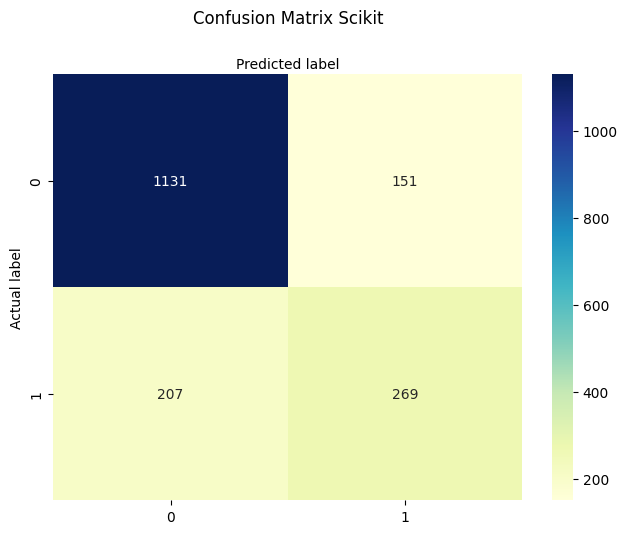

In [668]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix Scikit', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

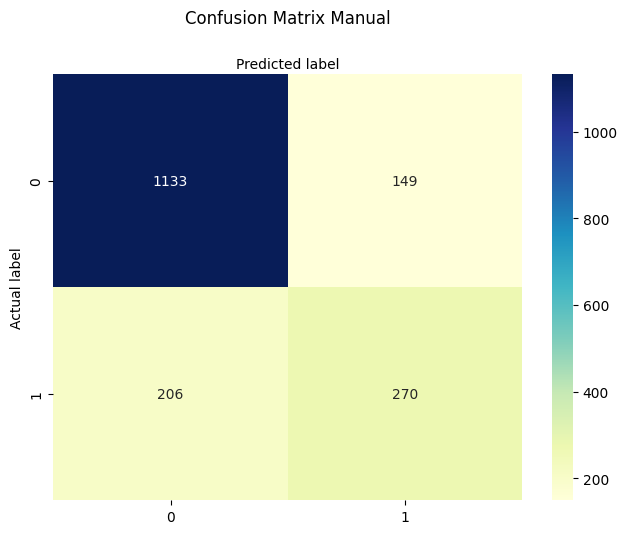

In [669]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix2), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix Manual', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [670]:
from sklearn.metrics import classification_report
target_names = ['No churn', 'Churn']

print("Pesos:           Scikit        Manual")
for i in range(len(logmanual.weights)):
    print(f"W{i+1:<2}        "f"{logsklearn.coef_[0][i]:>12.4f}  "f"{logmanual.weights[i]:>12.4f}")

print(f"Bias:      "f"{logsklearn.intercept_[0]:>12.4f}  "f"{logmanual.bias:>12.4f}\n\nClassification report:\n")
print("Scikit:")
print(classification_report(y_test2, y_pred_sklearn2, target_names=target_names, digits = 4))
print("Manual:")
print(classification_report(y_test2, y_pred_manual2, target_names=target_names, digits = 4))

Pesos:           Scikit        Manual
W1               0.0498        0.0487
W2              -0.0269       -0.0260
W3              -0.0672       -0.0666
W4              -1.3998       -1.4146
W5              -0.1475       -0.2683
W6               0.1385        0.1383
W7              -0.0525        0.5301
W8               0.6954        0.7170
W9              -0.0029       -0.0166
W10              0.2785        0.1806
W11              0.7744        0.2866
W12             -0.1490       -0.0793
W13             -0.1490       -0.0793
W14             -0.4036       -0.5032
W15             -0.1490       -0.0793
W16             -0.1806       -0.2812
W17             -0.1490       -0.0793
W18             -0.1185       -0.2150
W19             -0.1490       -0.0793
W20             -0.3730       -0.4720
W21             -0.1490       -0.0793
W22              0.2597        0.0662
W23             -0.1490       -0.0793
W24              0.1955        0.0006
W25             -0.6610       -0.6754
W26         

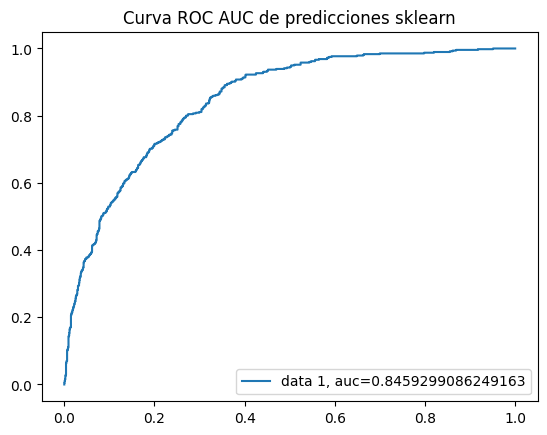

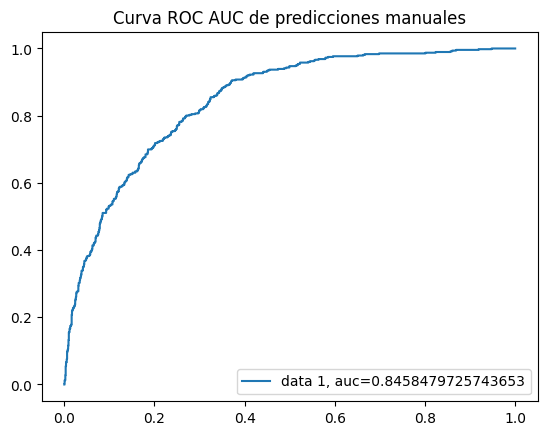

In [671]:
y_pred_proba_sklearn = logsklearn.predict_proba(X_test2)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test2,  y_pred_proba_sklearn)
auc_sklearn = metrics.roc_auc_score(y_test2, y_pred_proba_sklearn)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc_sklearn))
plt.legend(loc=4)
plt.title("Curva ROC AUC de predicciones sklearn")
plt.show()

y_pred_proba_manual = logmanual.predict_proba(X_test2)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test2,  y_pred_proba_manual)
auc_manual = metrics.roc_auc_score(y_test2, y_pred_proba_manual)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc_manual))
plt.legend(loc=4)
plt.title("Curva ROC AUC de predicciones manuales")
plt.show()